In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
import time

In [5]:
os.environ["CUDA_VISIBLE_DEVICES"]= str(5)

This Notebook contains all the results for the MSc Thesis of Olaf Verburg, with all results, the three subplots are shown (Losses, val recalls, test recalls). 
The results are presented in order of appearance in the paper and are visible without the log files (make sure not to rerun the cells, as it will remove the existing outputs)


Cell 5       Main table Amstertime 

Cell 6       Main table SPEDtest

Cell 7       Main table Nordland

Cell 8       Main table Eynsham

<!-- Cell 9       table 4 Eynsham BoQ

Cell 10      table 4 Nordland BoQ -->

Cell 9      table 5 Amstertime BoQ

Cell 10      table 5 Amstertime SALAD

Cell 11      table 5 Amstertime CricaVPR

Cell 12      table 6

Cell 13      table 8 Nordland

Cell 14      table 8 Eynsham

Cell 15      table 9 Nordland

Cell 16      table 9 Eynsham

Cell 17      patience plot



The graphs from the paper can be found in the TSNE visualization notebook in this git


In [30]:

def create_plot(method, dataset,lr=1e-7,num="",show_num=-1,dots=False,patience=None,print_shizzl=False):
    lr=str(lr)
    train_data='gsv'
    saved_path= f"../logs/{train_data}_{method}/logfile{train_data}_{method}_finetuned_on_{dataset}_{lr}_{num}.pth"
    # saved_path= "logs/gsv_crica/logfilegsv_crica_finetuned_on_nordland.pth1e-05"
    logfile=torch.load(saved_path)
    args=logfile['args']
    recall_value=1
    recalls=np.array(logfile["recalls"])[:show_num]
    recall_orig=np.array([recalls[0]]*len(recalls))[:show_num]
    losses=logfile['losses']
    avg_losses=[np.average(loss) for loss in losses][:show_num]

    fig,[ax1,ax2,ax3]=plt.subplots(1,3)

    plt.suptitle(f"Method {method} finetuned on {dataset} with lr {lr} and {args.queries_per_epoch} queries per epoch")
    ax1.set_title("losses")
    title=["Recall@1","Recall@5","Recall@10","Recall@20"]
    ax2.set_title('val recalls')
    ax3.set_title("test recalls ")
    # ax1.set_ylim([0,max(avg_losses)*1.2])
    ax1.plot(np.linspace(1,len(avg_losses),len(avg_losses)),avg_losses)

    ax2.plot(np.linspace(1,len(recalls),len(recalls)),recalls[:,0])
    ax2.plot(np.linspace(1,len(recalls),len(recalls)),recalls[:,1])
    ax2.plot(np.linspace(1,len(recalls),len(recalls)),recalls[:,2])
    ax2.plot(np.linspace(1,len(recalls),len(recalls)),recalls[:,3])
    ax2.legend(["R@1","R@5","R@10","R@20"])
    # ax2.plot(np.linspace(1,len(recalls),len(recalls)),recall_orig[:,0])
    # ax2.plot(np.linspace(1,len(recalls),len(recalls)),recall_orig[:,1])
    # ax2.plot(np.linspace(1,len(recalls),len(recalls)),recall_orig[:,2])
    # ax2.plot(np.linspace(1,len(recalls),len(recalls)),recall_orig[:,3])
    tests=np.array(logfile["test_set_recalls"][:show_num])
    # tests.insert(0,[91.2,96.2,97.5,98.5])

    # ax3.set_xticklabels([0,*logfile['best_epoch']])
    ax3.plot(np.linspace(1,len(tests),len(tests)),tests)

    # logfile["best_epoch"]
    r5_best=recalls[0][1]
    if print_shizzl:
#         print(args.trea)
        if "random_vals" in args.__dir__():
            print(num,args.train_positives_dist_threshold,args.random_vals)
        else:
            return
        print("original patience was",args.patience)
    not_improved_num=0
    if patience !=None:    
        args.patience=patience
    early_stopping_val=-1
    for i, recall_val in enumerate(recalls):


        r5_now= recall_val[1]
        if r5_now>r5_best:
            r5_best=r5_now
            early_stopping_val=i
            not_improved_num=0
        else:
            not_improved_num+=1

        if not_improved_num>(args.patience*np.ceil(args.queries_per_epoch/args.log_frequency)):
            print(not_improved_num)
            
            break
        elif (i==len(recalls)-1 and r5_now==r5_best):
            print("not stopped earlier")

#     print(early_stopping_val)
    
    
    if dots:
        ax3.scatter([early_stopping_val+1]*4,tests[early_stopping_val])
        ax2.scatter([early_stopping_val+1]*4,recalls[early_stopping_val])
    s=0
    
    plt.savefig(f"imgs/logs/{saved_path[8:-4]}.png")
    max_R5_val=np.argmax(recalls[:,1])
    best_epoch=logfile["best_epoch"][-1]
    best_evaluation=np.argwhere(np.array(logfile["best_epoch"])==best_epoch)[0]
    if print_shizzl:
        print(f"test recalls were {tests[early_stopping_val]} for the highest validation R@5")
        print(f"Original model results were {tests[0]} ")
        print(f"validation recalls were {recalls[early_stopping_val,1]} for the highest validation R@5")
        print(f"Original model validation results were {recalls[0,1]} ")
        if not_improved_num>(args.patience*np.ceil(args.queries_per_epoch/args.log_frequency)):
            print(f"Early stopping applied from logging {i}, best model is taken at {early_stopping_val}, current logging num: {len(recalls)}")
        else:
            print(f"Early stopping not applied yet, best model is taken at {early_stopping_val}, current logging num: {len(recalls)}")
#         print(f"best epoch num: {best_epoch}, based on a patience of {args.patience}")

#         # # for s in range(0,4):
#         #     print(f"for recall {recall_values[s]} the highest val is {max(recalls[:,s]):.2f} the highest test was {max(tests[:,s]):.2f} and the test R when max val was {tests[np.argmax(recalls[:,s])][s]:.2f}")

#         print(args.lr)
#         print(args.early_stopping,early_stopping_val)
        if "times_per_loop" in logfile.keys():
            times=np.array(logfile["times_per_loop"])
            print(f"this run took {times.sum()} till {time.ctime(os.path.getmtime(saved_path))}")
#             print(f"average epoch took{times.mean()} and median: {np.median(times)}")
        
#             print(f"augmentations: {args.augments}")
#             print(f"amount of loggings: {len(recalls)}")
            
#         print(f"this logfile was created on {time.ctime(os.path.getctime(saved_path))}")
    return avg_losses

In [7]:

def create_plot_r5_patience(method, dataset,lr=1e-7,num="",show_num=-1,dots=False,recall_value=1,patience_max=None,print_shizzl=False):
    lr=str(lr)
    train_data='gsv'
    saved_path= f"../logs/{train_data}_{method}/logfile{train_data}_{method}_finetuned_on_{dataset}_{lr}_{num}.pth"
    # saved_path= "logs/gsv_crica/logfilegsv_crica_finetuned_on_nordland.pth1e-05"
    logfile=torch.load(saved_path)
    args=logfile['args']
    
    recalls=np.array(logfile["recalls"])[:show_num]
    recall_orig=np.array([recalls[0]]*len(recalls))[:show_num]
    losses=logfile['losses']
    avg_losses=[np.average(loss) for loss in losses][:show_num]

#     fig,[ax1,ax2,ax3]=plt.subplots(1,3)

#     plt.suptitle(f"Method {method} finetuned on {dataset} with lr {lr} and {args.queries_per_epoch} queries per epoch")
#     ax1.set_title("losses")
    titles=["Recall@1","Recall@5","Recall@10","Recall@20"]
#     ax2.set_title('val recalls')
#     ax3.set_title("test recalls ")
#     # ax1.set_ylim([0,max(avg_losses)*1.2])
#     ax1.plot(np.linspace(1,len(avg_losses),len(avg_losses)),avg_losses)

#     ax2.plot(np.linspace(1,len(recalls),len(recalls)),recalls[:,0])
#     ax2.plot(np.linspace(1,len(recalls),len(recalls)),recalls[:,1])
#     ax2.plot(np.linspace(1,len(recalls),len(recalls)),recalls[:,2])
#     ax2.plot(np.linspace(1,len(recalls),len(recalls)),recalls[:,3])
#     ax2.legend(["R@1","R@5","R@10","R@20"])
#     # ax2.plot(np.linspace(1,len(recalls),len(recalls)),recall_orig[:,0])
#     # ax2.plot(np.linspace(1,len(recalls),len(recalls)),recall_orig[:,1])
#     # ax2.plot(np.linspace(1,len(recalls),len(recalls)),recall_orig[:,2])
#     # ax2.plot(np.linspace(1,len(recalls),len(recalls)),recall_orig[:,3])
    tests=np.array(logfile["test_set_recalls"][:show_num])
#     # tests.insert(0,[91.2,96.2,97.5,98.5])

#     # ax3.set_xticklabels([0,*logfile['best_epoch']])
#     ax3.plot(np.linspace(1,len(tests),len(tests)),tests)

    # logfile["best_epoch"]
    r5_patience=[]
    
    for patience in range(0,patience_max):
        
        r5_best=recalls[0][1]
        not_improved_num=0
        early_stopping_val=0
        
        for i, recall_val in enumerate(recalls):

            r5_now= recall_val[1]
            if r5_now>r5_best:
                r5_best=r5_now
                early_stopping_val=i
                not_improved_num=0
            else:
                not_improved_num+=1

            if not_improved_num>(patience*np.ceil(args.queries_per_epoch/args.log_frequency)):

                break
            elif (i==len(recalls)-1 and r5_now==r5_best):
                continue
                    
#                 print("not stopped earlier")

#         print(early_stopping_val)
#         print(tests[1])
#         print(args.seed)
#         print(early_stopping_val)
#         print(tests)
        if early_stopping_val==-1:
            r5_patience.append(0)
        r5_patience.append(tests[early_stopping_val][recall_value])
    
    
#     plt.plot(range(0,patience_max),r5_patience)
#     plt.scatter(15,r5_patience[15],c='r')
#     plt.title(f"{titles[recall_value]} on dataset {dataset} with method {method}" )
#     plt.ylabel(f"{titles[recall_value]}")
#     plt.xlabel(f"patience value")
               
#     plt.show()
            
    return r5_patience

Namespace(datasets_folder='datasets_vg/datasets', dataset_name='amstertime', method='boq', num_workers=6, train_batch_size=16, seed=0, infer_batch_size=16, mining='full', lr=1e-07, margin=0.1, criterion='triplet', optim='adam', negs_num_per_query=2, epochs_num=200, resume='weights/gsv_boq.pth', queries_per_epoch=862, patience=15, test_method='hard_resize', augments=True, create_augments=False, use_val_augments=True, val_save_dir='/home/osverburg/validation', log_dir='logs', device='cuda', gpu_id='6', pca=False, pca_folder=None, val_positive_dist_threshold=25, train_positives_dist_threshold=10, backbone='DINOV2', registers=False, rerank_num=100, descriptors_dimension=12288, dense_feature_map_size=[61, 61, 128], recall_values=[1, 5, 10, 20], no_labels=False, resize=[322, 322], efficient_ram_testing=False, neg_samples_num=1000, is_trainref=True, ckpnt_path=None, train_backbone='original with model.eval', train_aggregator=True, image_size=[322, 322], features_dim=12288, triplets=False, cac

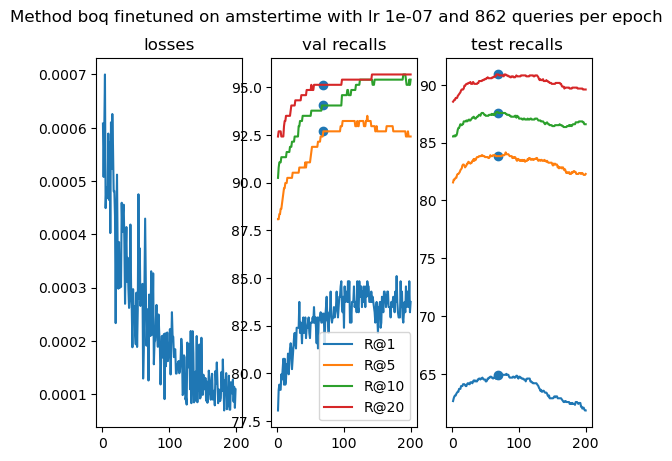

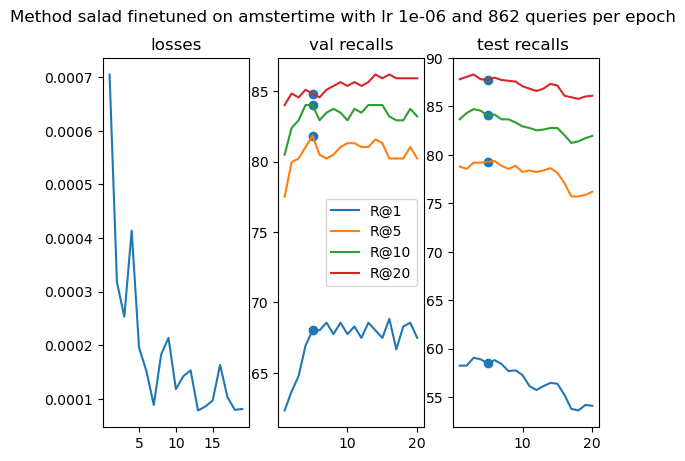

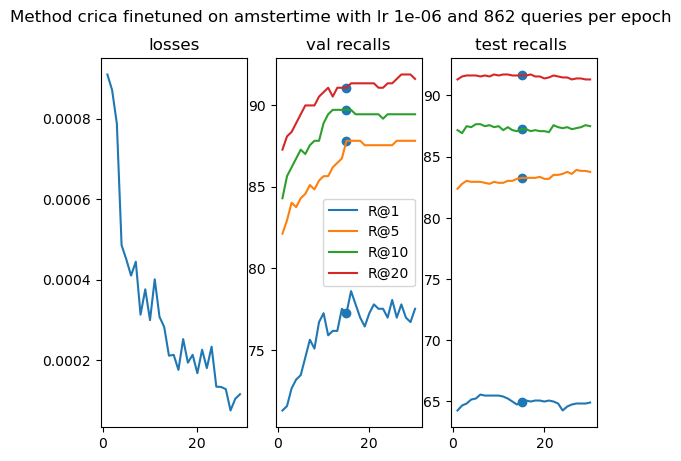

In [8]:
patience=15
show_num=-1
recall_value=1
dots=True  
print_shizzl=True
loss1=create_plot('boq','amstertime',lr=1e-7,num=1,show_num=show_num,dots=dots,patience=patience,print_shizzl=print_shizzl)
loss1=create_plot("salad",'amstertime',lr=1e-6,num=0,show_num=show_num,dots=dots,patience=patience,print_shizzl=print_shizzl)
loss1=create_plot('crica','amstertime',lr=1e-6,num=18,show_num=show_num,dots=dots,patience=patience,print_shizzl=print_shizzl)


Namespace(datasets_folder='datasets_vg/datasets', dataset_name='sped', method='boq', num_workers=6, train_batch_size=16, seed=0, infer_batch_size=16, mining='full', lr=1e-07, margin=0.1, criterion='triplet', optim='adam', negs_num_per_query=2, epochs_num=200, resume='weights/gsv_boq.pth', queries_per_epoch=425, patience=15, test_method='hard_resize', augments=True, create_augments=False, use_val_augments=True, val_save_dir='/home/osverburg/validation', log_dir='logs', device='cuda', gpu_id='6', pca=False, pca_folder=None, val_positive_dist_threshold=25, train_positives_dist_threshold=10, backbone='DINOV2', registers=False, rerank_num=100, descriptors_dimension=12288, dense_feature_map_size=[61, 61, 128], recall_values=[1, 5, 10, 20], no_labels=False, resize=[322, 322], efficient_ram_testing=False, neg_samples_num=1000, is_trainref=True, ckpnt_path=None, image_size=[322, 322], features_dim=12288, triplets=False, cache_refresh_rate=425, log_frequency=425, early_stopping=True, early_stopp

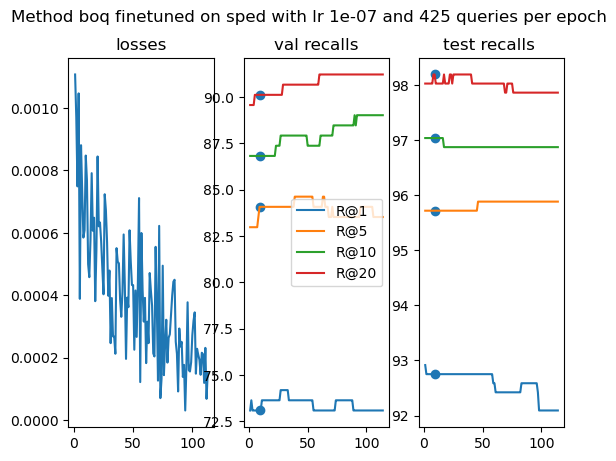

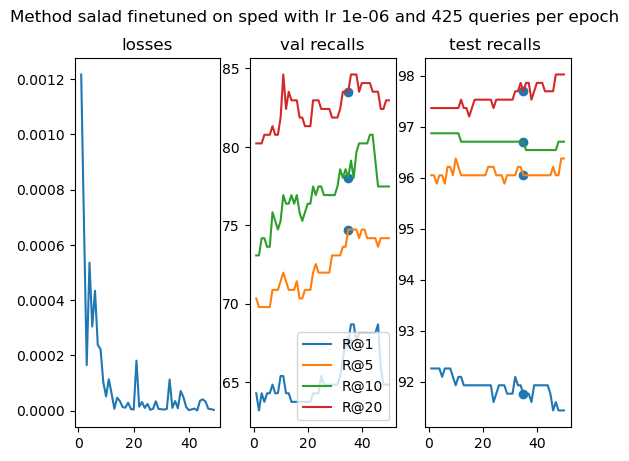

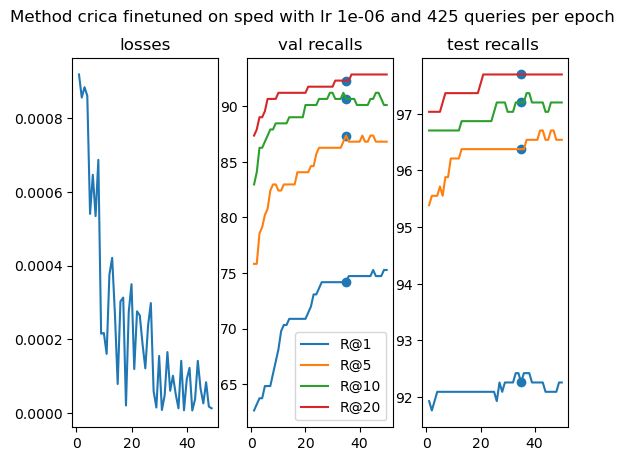

In [272]:
show_num=-1
patience=15
loss1=create_plot('boq','sped',lr=1e-7,num=12,show_num=show_num,dots=True,patience=patience,print_shizzl=True)
loss1=create_plot("salad",'sped',lr=1e-6,num=0,show_num=show_num,dots=True,patience=patience,print_shizzl=True)
loss1=create_plot('crica','sped',lr=1e-6,num=0,show_num=show_num,dots=True,patience=patience,print_shizzl=True)
# loss1=create_plot('crica','sped',lr=lr,num=4,show_num=show_num,dots=True,patience=patience,print_shizzl=True)


Namespace(datasets_folder='datasets_vg/datasets', dataset_name='nordland', method='boq', num_workers=6, train_batch_size=16, seed=0, infer_batch_size=16, mining='full', lr=1e-07, margin=0.1, criterion='triplet', optim='adam', negs_num_per_query=2, epochs_num=100, log_frequency=1008, resume='weights/gsv_boq.pth', queries_per_epoch=19315, patience=5, test_method='hard_resize', augments=True, create_augments=False, use_val_augments=True, val_save_dir='/home/osverburg/validation', log_dir='logs', device='cuda', gpu_id='6', pca=False, pca_folder=None, val_positive_dist_threshold=25, train_positives_dist_threshold=10, backbone='DINOV2', descriptors_dimension=12288, recall_values=[1, 5, 10, 20], no_labels=False, resize=[322, 322], efficient_ram_testing=False, neg_samples_num=1000, ckpnt_path=None, is_trainref=True, is_best=False, image_size=[322, 322], features_dim=12288, triplets=False, cache_refresh_rate=19315, early_stopping=False, early_stopping_epoch=6, save_dir='logs/gsv_boq')
original 

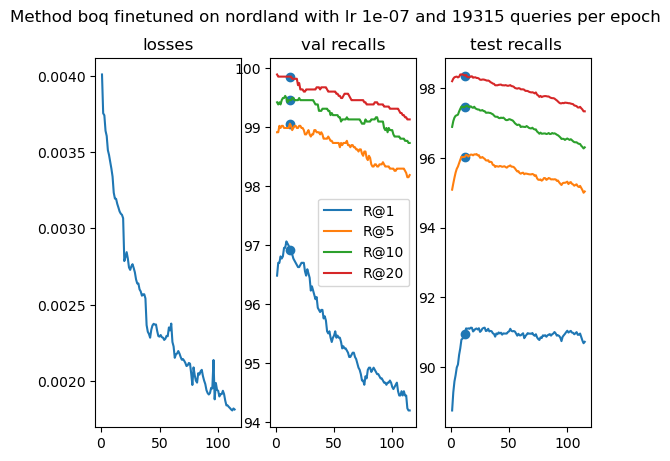

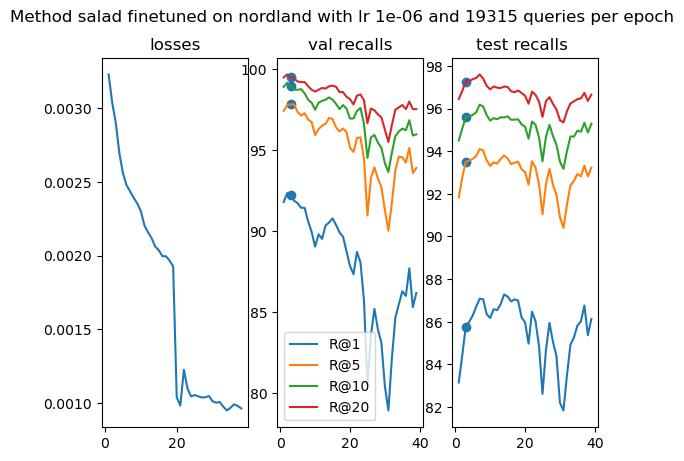

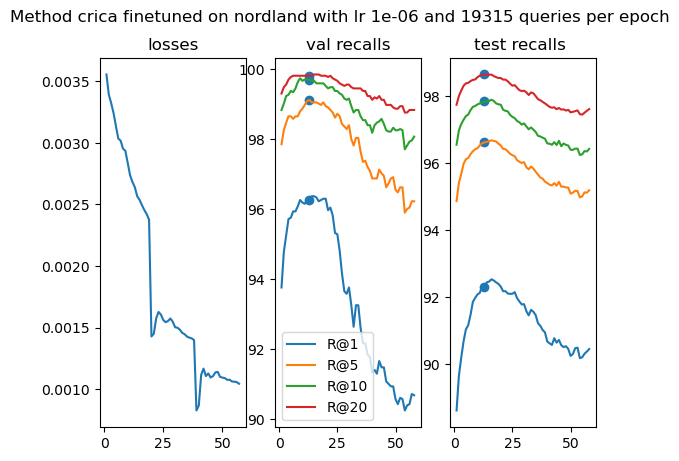

In [275]:
show_num=-1
loss1=create_plot('boq','nordland',lr=1e-7,num=0,show_num=show_num,dots=True,patience=patience,print_shizzl=True)
loss1=create_plot("salad",'nordland',lr=1e-6,num="",show_num=show_num,dots=True,patience=patience,print_shizzl=True)
loss1=create_plot('crica','nordland',lr=1e-6,num=8,show_num=show_num,dots=True,patience=patience,print_shizzl=True)


Namespace(datasets_folder='datasets_vg/datasets', dataset_name='eynsham', method='boq', num_workers=6, train_batch_size=16, seed=0, infer_batch_size=16, mining='full', lr=1e-07, margin=0.1, criterion='triplet', optim='adam', negs_num_per_query=2, epochs_num=100, log_frequency=1008, resume='weights/gsv_boq.pth', queries_per_epoch=16755, patience=5, test_method='hard_resize', augments=True, create_augments=False, use_val_augments=True, val_save_dir='/home/osverburg/validation', log_dir='logs', device='cuda', gpu_id='6', pca=False, pca_folder=None, val_positive_dist_threshold=25, train_positives_dist_threshold=10, backbone='DINOV2', registers=False, rerank_num=100, descriptors_dimension=12288, dense_feature_map_size=[61, 61, 128], recall_values=[1, 5, 10, 20], no_labels=False, resize=[322, 322], efficient_ram_testing=False, neg_samples_num=1000, ckpnt_path=None, is_trainref=True, is_best=False, image_size=[322, 322], features_dim=12288, triplets=False, cache_refresh_rate=16755, early_stop

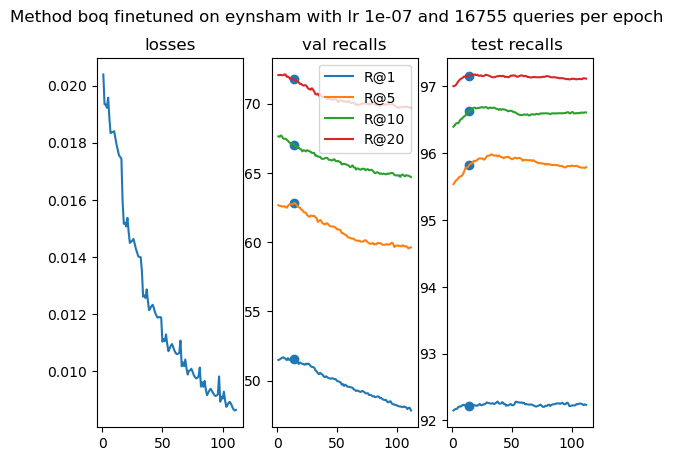

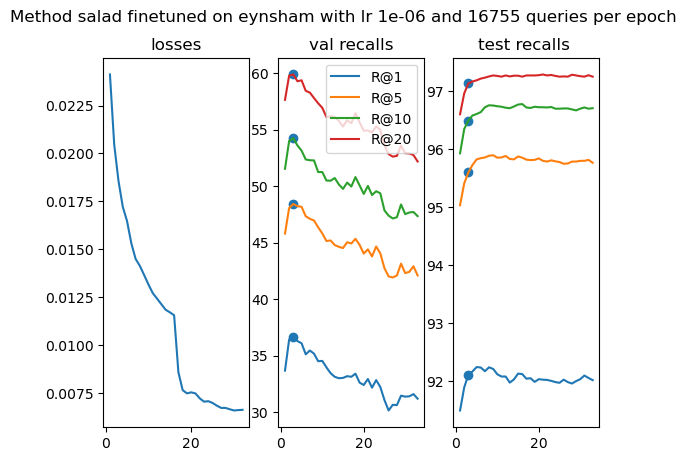

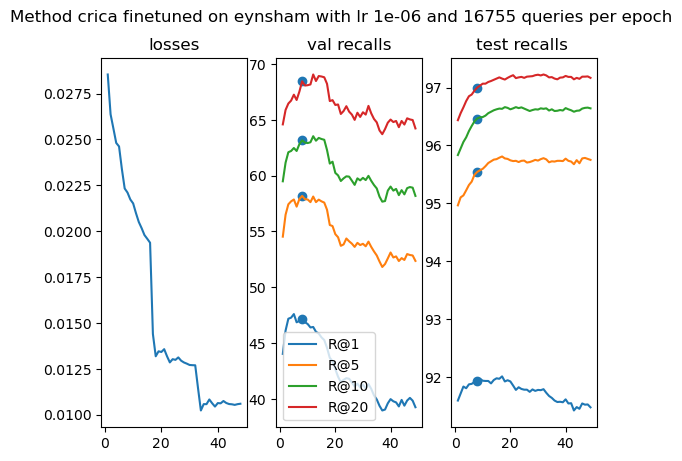

In [279]:
show_num=-1
loss1=create_plot('boq','eynsham',lr=1e-7,num=1,show_num=show_num,dots=True,patience=patience,print_shizzl=True)
loss1=create_plot("salad",'eynsham',lr=1e-6,num="",show_num=show_num,dots=True,patience=patience,print_shizzl=True)
loss1=create_plot('crica','eynsham',lr=1e-6,num="",show_num=show_num,dots=True,patience=patience,print_shizzl=True)


Namespace(datasets_folder='../datasets_vg/datasets', dataset_name='amstertime', method='boq', original_training_data='gsv', num_workers=6, train_batch_size=16, seed=0, infer_batch_size=16, mining='full', lr=0.0001, margin=0.1, criterion='triplet', optim='adam', negs_num_per_query=2, epochs_num=1000, log_frequency=862, ablation=False, ablation_nordland=False, save_models=True, test_val_queries=0.1, grayscale=False, exact_match=False, resume='', queries_per_epoch=862, patience=1000, test_method='hard_resize', augments=True, create_augments=False, use_val_augments=True, val_save_dir='/home/osverburg/validation', log_dir='../logs', device='cuda', gpu_id='6', pca=False, pca_folder=None, val_positive_dist_threshold=25, train_positives_dist_threshold=10, backbone='DINOV2', descriptors_dimension=12288, recall_values=[1, 5, 10, 20], no_labels=False, resize=[322, 322], efficient_ram_testing=False, neg_samples_num=1000, ckpnt_path=None, is_trainref=True, is_best=False, image_size=[322, 322], feat

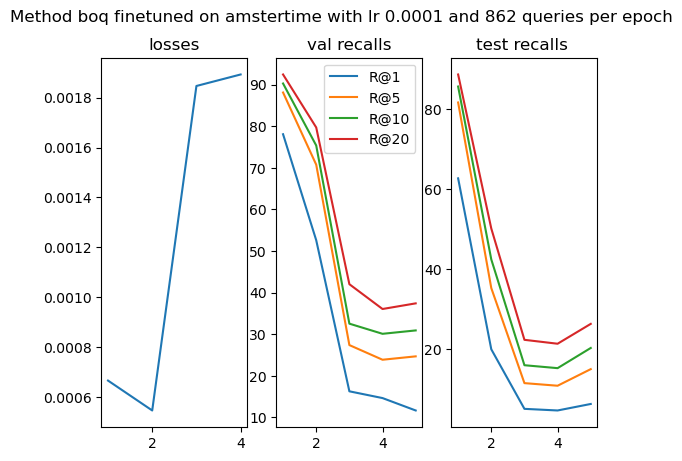

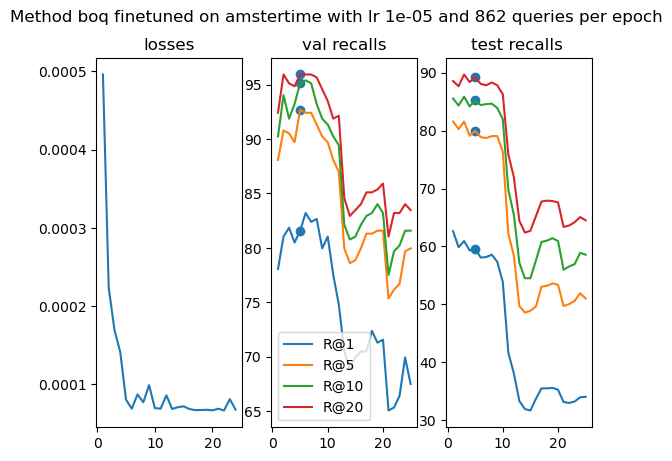

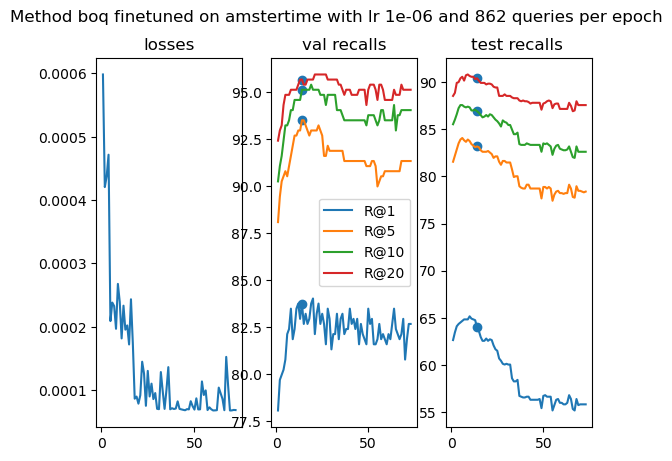

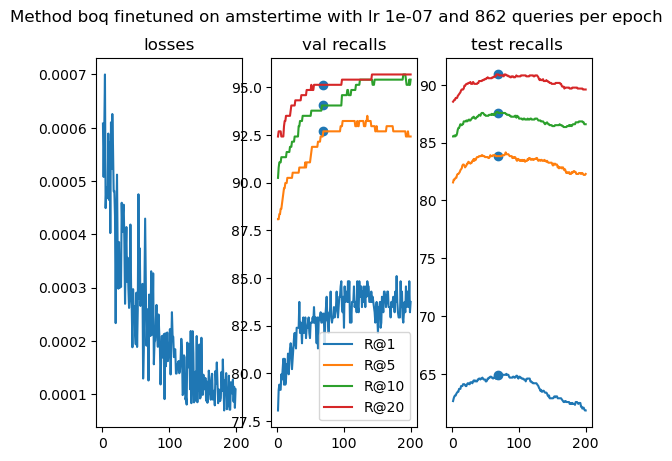

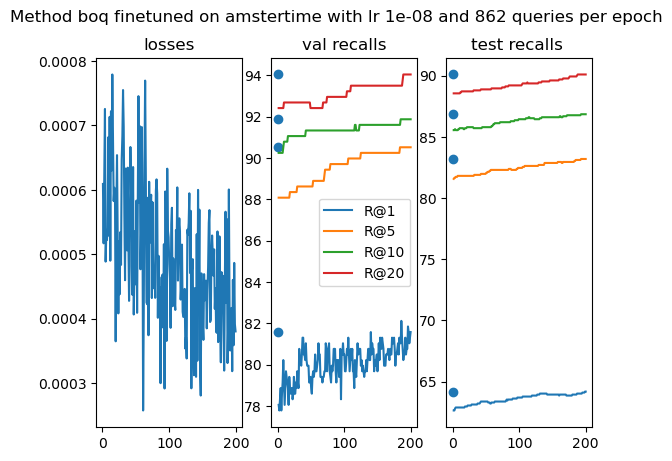

In [287]:
patience=None
loss1=create_plot('boq','amstertime',lr=1e-4,num="",show_num=show_num,dots=False,patience=patience,print_shizzl=print_shizzl)
loss1=create_plot('boq','amstertime',lr=1e-5,num="",show_num=show_num,dots=dots,patience=patience,print_shizzl=print_shizzl)
loss1=create_plot('boq','amstertime',lr=1e-6,num="",show_num=show_num,dots=dots,patience=patience,print_shizzl=print_shizzl)
loss1=create_plot('boq','amstertime',lr=1e-7,num=1,show_num=show_num,dots=dots,patience=patience,print_shizzl=print_shizzl)
loss1=create_plot('boq','amstertime',lr=1e-8,num="",show_num=show_num,dots=dots,patience=patience,print_shizzl=print_shizzl)


Namespace(datasets_folder='../datasets_vg/datasets', dataset_name='amstertime', method='crica', original_training_data='gsv', num_workers=6, train_batch_size=16, seed=0, infer_batch_size=16, mining='full', lr=0.0001, margin=0.1, criterion='triplet', optim='adam', negs_num_per_query=2, epochs_num=400, log_frequency=862, ablation=False, ablation_nordland=False, save_models=False, test_val_queries=0.1, grayscale=False, exact_match=False, resume='', queries_per_epoch=862, patience=150, test_method='hard_resize', augments=True, create_augments=False, use_val_augments=True, val_save_dir='/home/osverburg/validation', log_dir='../logs', device='cuda', gpu_id='5', pca=False, pca_folder=None, random_vals=True, stop_after_patience=True, val_split=0.3, val_positive_dist_threshold=25, train_positives_dist_threshold=10, backbone=None, descriptors_dimension=10752, recall_values=[1, 5, 10, 20], no_labels=False, resize=[224, 224], efficient_ram_testing=False, neg_samples_num=1000, ckpnt_path=None, is_t

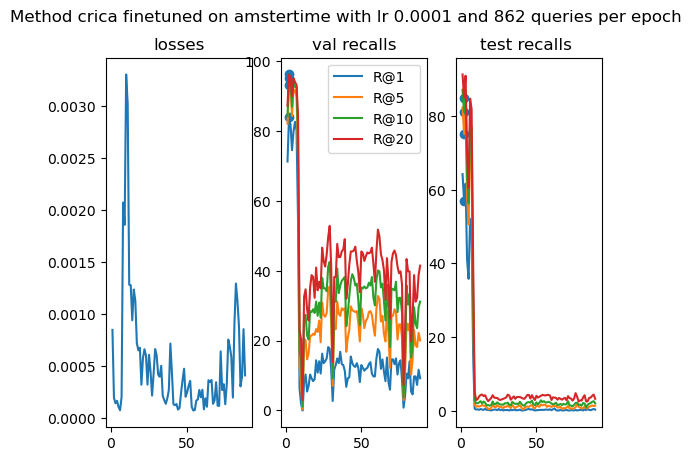

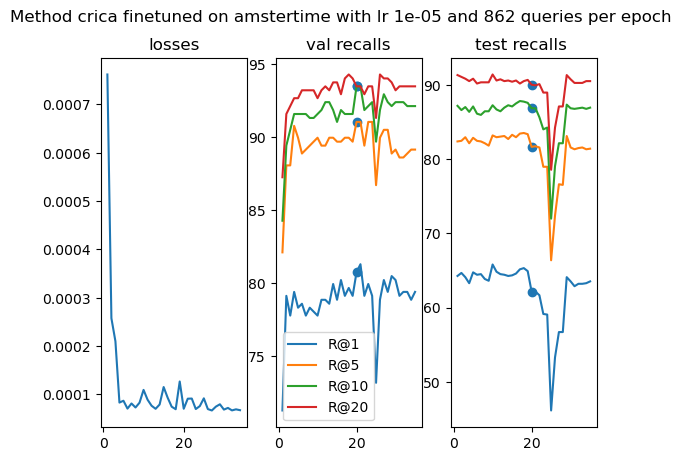

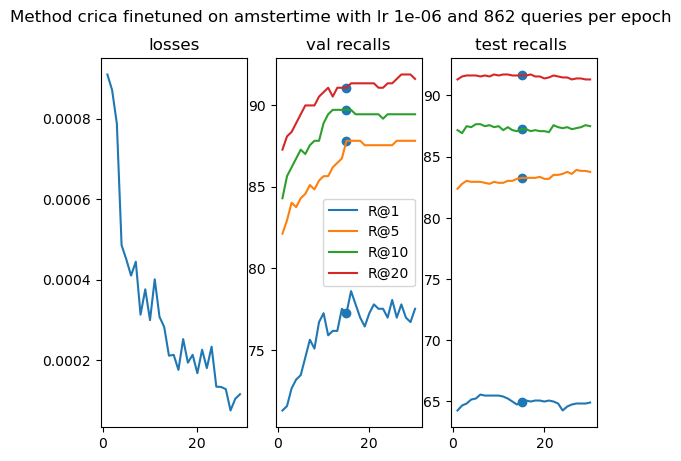

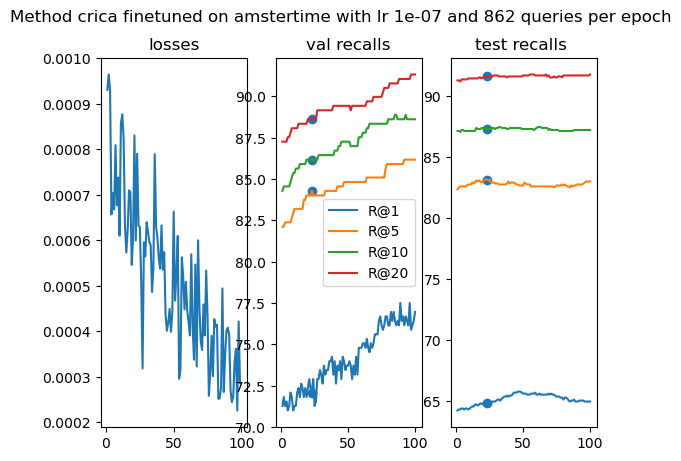

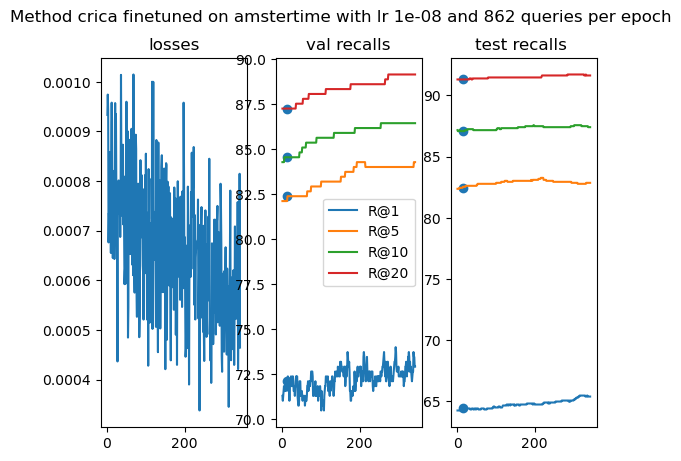

In [294]:
patience= 15
loss1=create_plot('crica','amstertime',lr=1e-4,num="6",show_num=show_num,dots=dots,patience=patience,print_shizzl=print_shizzl)
loss1=create_plot('crica','amstertime',lr=1e-5,num="9",show_num=show_num,dots=dots,patience=patience,print_shizzl=print_shizzl)
loss1=create_plot('crica','amstertime',lr=1e-6,num=18,show_num=show_num,dots=dots,patience=patience,print_shizzl=print_shizzl)
loss1=create_plot('crica','amstertime',lr=1e-7,num="21",show_num=show_num,dots=dots,patience=patience,print_shizzl=print_shizzl)
loss1=create_plot('crica','amstertime',lr=1e-8,num="3",show_num=show_num,dots=dots,patience=patience,print_shizzl=print_shizzl)


Namespace(datasets_folder='../datasets_vg/datasets', dataset_name='amstertime', method='salad', original_training_data='gsv', num_workers=6, train_batch_size=16, seed=0, infer_batch_size=16, mining='full', lr=0.0001, margin=0.1, criterion='triplet', optim='adam', negs_num_per_query=2, epochs_num=400, log_frequency=862, ablation=False, ablation_nordland=False, save_models=False, test_val_queries=0.1, grayscale=False, exact_match=False, resume='', queries_per_epoch=862, patience=15, test_method='hard_resize', augments=True, create_augments=False, use_val_augments=True, val_save_dir='/home/osverburg/validation', log_dir='../logs', device='cuda', gpu_id='7', pca=False, pca_folder=None, random_vals=True, stop_after_patience=True, val_split=0.3, val_positive_dist_threshold=25, train_positives_dist_threshold=10, backbone=None, descriptors_dimension=8448, recall_values=[1, 5, 10, 20], no_labels=False, resize=[322, 322], efficient_ram_testing=False, neg_samples_num=1000, ckpnt_path=None, is_tra

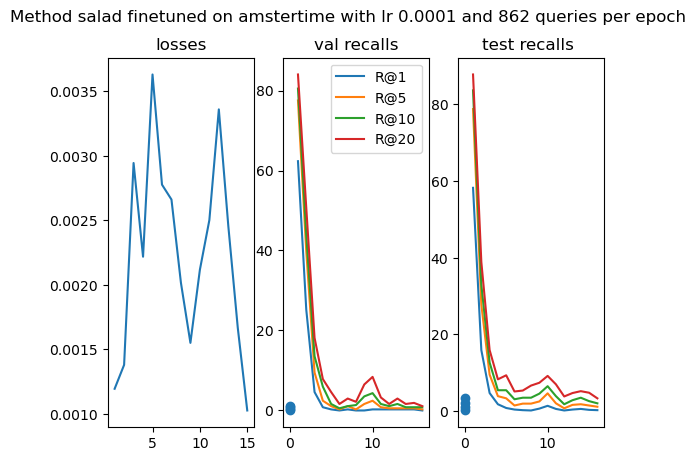

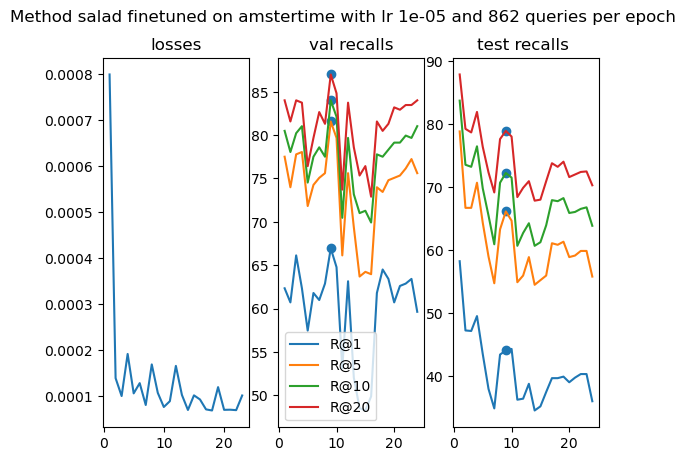

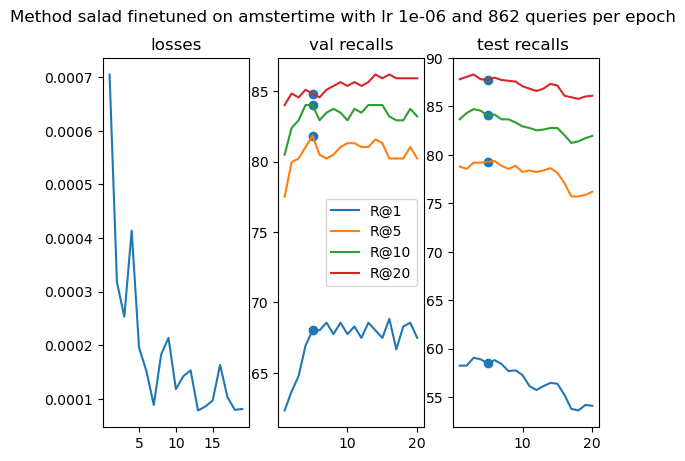

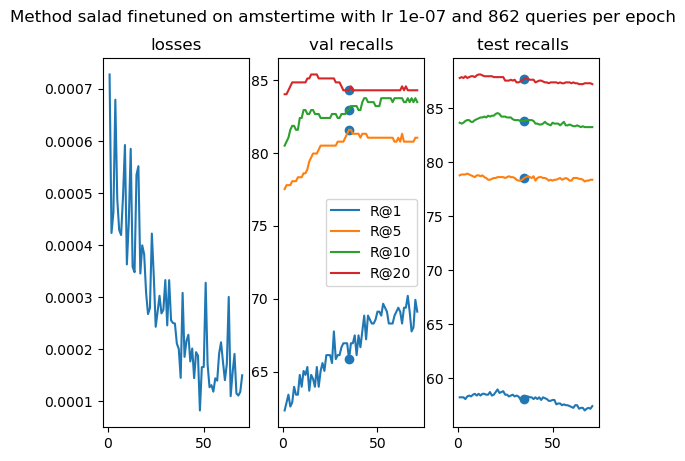

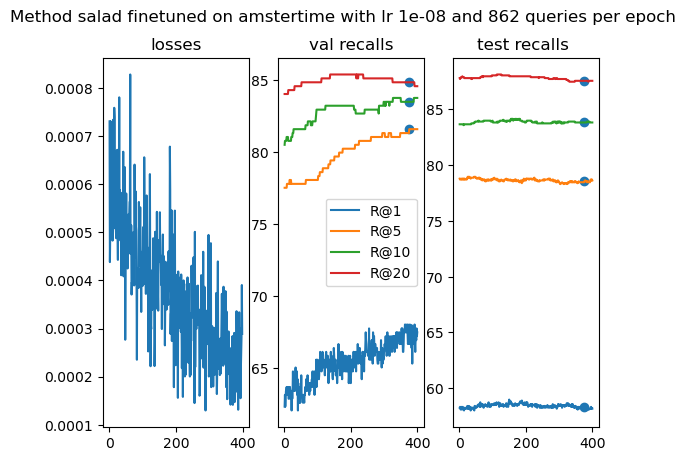

In [292]:
loss1=create_plot("salad",'amstertime',lr=1e-4,num="",show_num=show_num,dots=dots,patience=patience,print_shizzl=print_shizzl)
loss1=create_plot("salad",'amstertime',lr=1e-5,num="",show_num=show_num,dots=dots,patience=patience,print_shizzl=print_shizzl)
loss1=create_plot("salad",'amstertime',lr=1e-6,num=0,show_num=show_num,dots=dots,patience=patience,print_shizzl=print_shizzl)
loss1=create_plot("salad",'amstertime',lr=1e-7,num="5",show_num=show_num,dots=dots,patience=patience,print_shizzl=print_shizzl)
loss1=create_plot("salad",'amstertime',lr=1e-8,num="",show_num=show_num,dots=dots,patience=patience,print_shizzl=print_shizzl)


Namespace(datasets_folder='../datasets_vg/datasets', dataset_name='nordland', method='boq', num_workers=6, train_batch_size=16, seed=0, infer_batch_size=16, mining='full', lr=1e-07, margin=0.1, criterion='triplet', optim='adam', negs_num_per_query=2, epochs_num=100, log_frequency=1008, ablation=False, ablation_nordland=False, save_models=True, test_val_queries=0.05, grayscale=False, exact_match=False, resume='weights/gsv_boq.pth', queries_per_epoch=19315, patience=5, test_method='hard_resize', augments=True, create_augments=False, use_val_augments=True, val_save_dir='/home/osverburg/validation', log_dir='../logs', device='cuda', gpu_id='5', pca=False, pca_folder=None, val_positive_dist_threshold=25, train_positives_dist_threshold=10, backbone='DINOV2', descriptors_dimension=12288, recall_values=[1, 5, 10, 20], no_labels=False, resize=[322, 322], efficient_ram_testing=False, neg_samples_num=1000, ckpnt_path=None, is_trainref=True, is_best=False, image_size=[322, 322], features_dim=12288

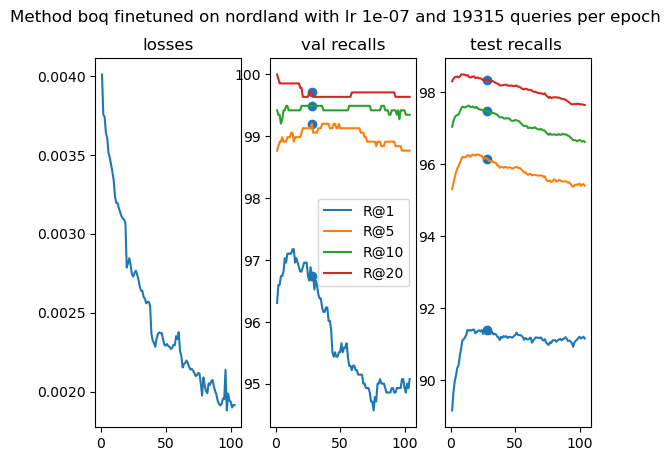

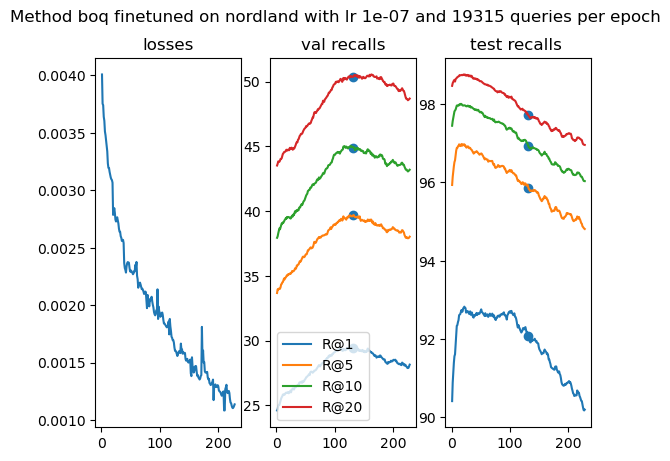

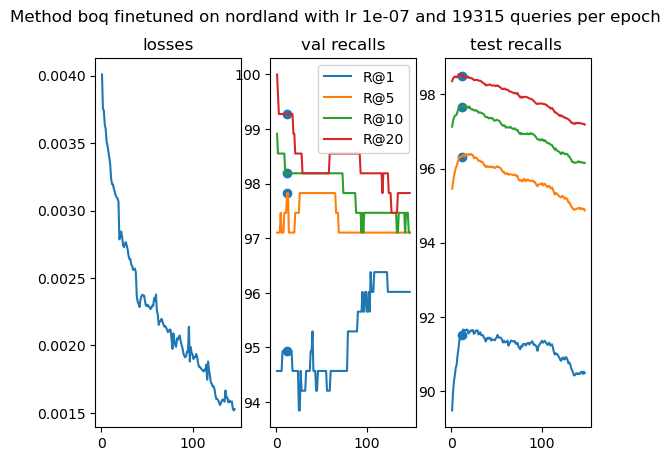

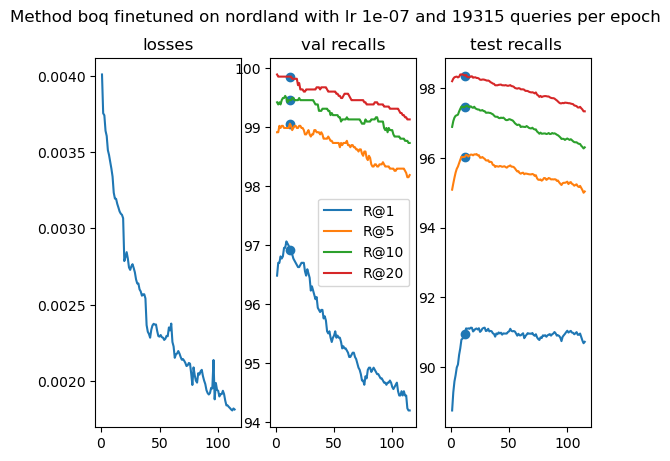

In [297]:
loss1=create_plot("boq",'nordland',lr=1e-7,num="4",show_num=show_num,dots=True,patience=None,print_shizzl=print_shizzl)
loss1=create_plot("boq",'nordland',lr=1e-7,num="5",show_num=show_num,dots=True,patience=None,print_shizzl=print_shizzl)
loss1=create_plot("boq",'nordland',lr=1e-7,num="6",show_num=show_num,dots=True,patience=None,print_shizzl=print_shizzl)
loss1=create_plot("boq",'nordland',lr=1e-7,num="0",show_num=show_num,dots=True,patience=None,print_shizzl=print_shizzl)
# loss1=create_plot("boq",'nordland',lr=1e-7,num="7",show_num=show_num,dots=True,patience=None,print_shizzl=print_shizzl)


Namespace(datasets_folder='datasets_vg/datasets', dataset_name='nordland', method='boq', num_workers=6, train_batch_size=16, seed=0, infer_batch_size=16, mining='full', lr=1e-07, margin=0.1, criterion='triplet', optim='adam', negs_num_per_query=2, epochs_num=100, log_frequency=1008, resume='weights/gsv_boq.pth', queries_per_epoch=19315, patience=5, test_method='hard_resize', augments=True, create_augments=False, use_val_augments=True, val_save_dir='/home/osverburg/validation', log_dir='logs', device='cuda', gpu_id='6', pca=False, pca_folder=None, val_positive_dist_threshold=25, train_positives_dist_threshold=10, backbone='DINOV2', descriptors_dimension=12288, recall_values=[1, 5, 10, 20], no_labels=False, resize=[322, 322], efficient_ram_testing=False, neg_samples_num=1000, ckpnt_path=None, is_trainref=True, is_best=False, image_size=[322, 322], features_dim=12288, triplets=False, cache_refresh_rate=19315, early_stopping=False, early_stopping_epoch=6, save_dir='logs/gsv_boq')
original 

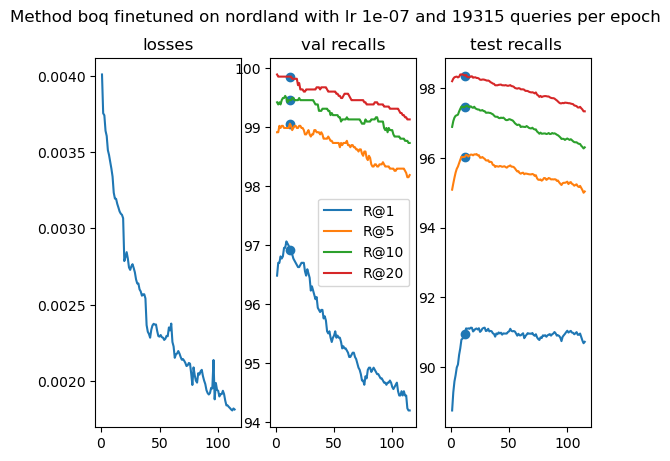

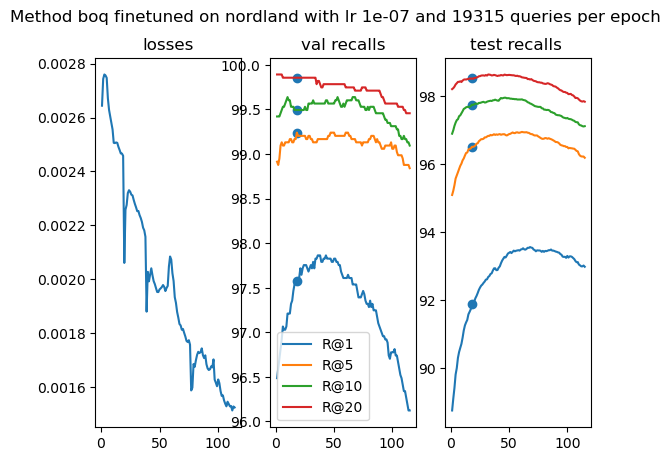

In [298]:
loss1=create_plot("boq",'nordland',lr=1e-7,num="0",show_num=show_num,dots=True,patience=None,print_shizzl=print_shizzl)
loss1=create_plot("boq",'nordland',lr=1e-7,num="7",show_num=show_num,dots=True,patience=None,print_shizzl=print_shizzl)
# loss1=create_plot("boq",'nordland',lr=1e-7,num="0",show_num=show_num,dots=True,patience=None,print_shizzl=print_shizzl)
# loss1=create_plot("boq",'nordland',lr=1e-7,num="7",show_num=show_num,dots=True,patience=None,print_shizzl=print_shizzl)


Namespace(datasets_folder='datasets_vg/datasets', dataset_name='eynsham', method='boq', num_workers=6, train_batch_size=16, seed=0, infer_batch_size=16, mining='full', lr=1e-07, margin=0.1, criterion='triplet', optim='adam', negs_num_per_query=2, epochs_num=100, log_frequency=1008, resume='weights/gsv_boq.pth', queries_per_epoch=16755, patience=5, test_method='hard_resize', augments=True, create_augments=False, use_val_augments=True, val_save_dir='/home/osverburg/validation', log_dir='logs', device='cuda', gpu_id='6', pca=False, pca_folder=None, val_positive_dist_threshold=25, train_positives_dist_threshold=10, backbone='DINOV2', registers=False, rerank_num=100, descriptors_dimension=12288, dense_feature_map_size=[61, 61, 128], recall_values=[1, 5, 10, 20], no_labels=False, resize=[322, 322], efficient_ram_testing=False, neg_samples_num=1000, ckpnt_path=None, is_trainref=True, is_best=False, image_size=[322, 322], features_dim=12288, triplets=False, cache_refresh_rate=16755, early_stop

RuntimeError: PytorchStreamReader failed reading zip archive: failed finding central directory

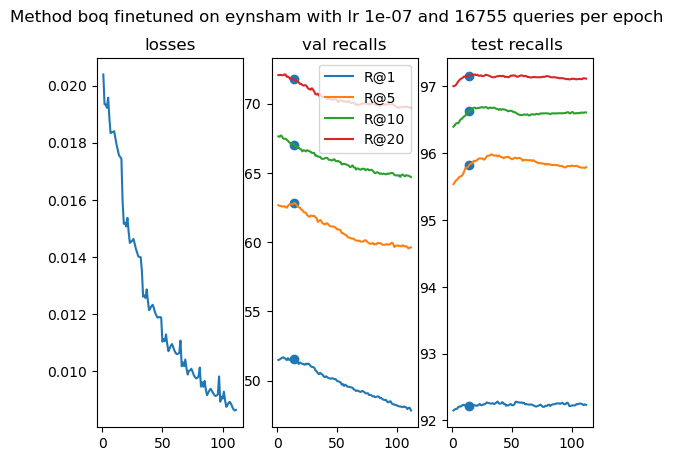

In [313]:
loss1=create_plot('boq','eynsham',lr=1e-7,num=1,show_num=show_num,dots=True,patience=patience,print_shizzl=True)
loss1=create_plot('boq','eynsham',lr=1e-7,num=2,show_num=show_num,dots=True,patience=patience,print_shizzl=True)


Namespace(datasets_folder='datasets_vg/datasets', dataset_name='nordland', method='boq', num_workers=6, train_batch_size=16, seed=0, infer_batch_size=16, mining='full', lr=1e-07, margin=0.1, criterion='triplet', optim='adam', negs_num_per_query=2, epochs_num=100, log_frequency=1008, resume='weights/gsv_boq.pth', queries_per_epoch=19315, patience=5, test_method='hard_resize', augments=True, create_augments=False, use_val_augments=True, val_save_dir='/home/osverburg/validation', log_dir='logs', device='cuda', gpu_id='6', pca=False, pca_folder=None, val_positive_dist_threshold=25, train_positives_dist_threshold=10, backbone='DINOV2', descriptors_dimension=12288, recall_values=[1, 5, 10, 20], no_labels=False, resize=[322, 322], efficient_ram_testing=False, neg_samples_num=1000, ckpnt_path=None, is_trainref=True, is_best=False, image_size=[322, 322], features_dim=12288, triplets=False, cache_refresh_rate=19315, early_stopping=False, early_stopping_epoch=6, save_dir='logs/gsv_boq')
original 

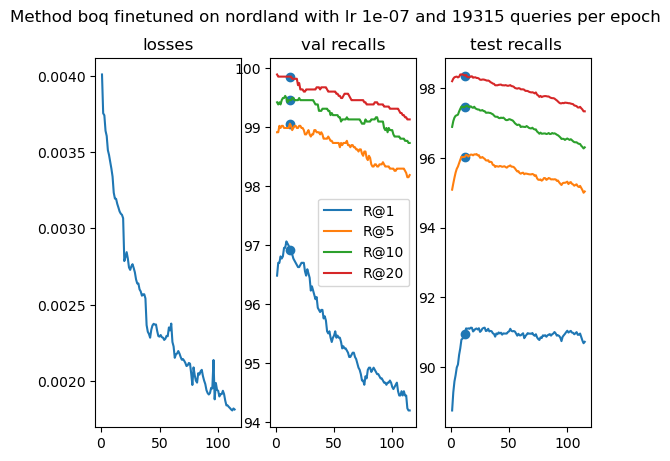

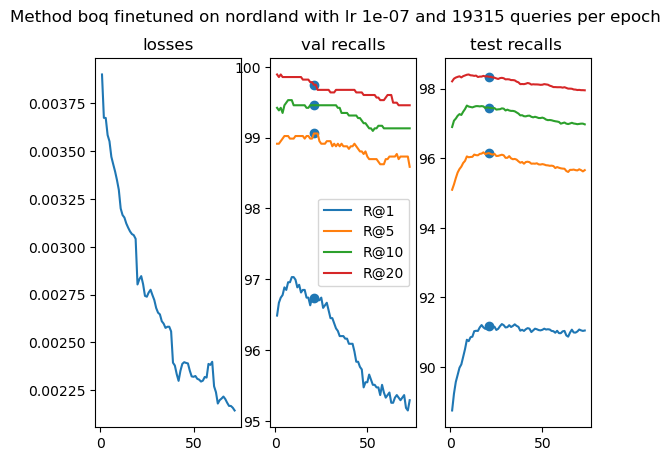

In [317]:
loss1=create_plot("boq",'nordland',lr=1e-7,num="0",show_num=show_num,dots=True,patience=None,print_shizzl=print_shizzl)
loss1=create_plot("boq",'nordland',lr=1e-7,num="10",show_num=show_num,dots=True,patience=None,print_shizzl=print_shizzl)
# loss1=create_plot("boq",'nordland',lr=1e-7,num="0",show_num=show_num,dots=True,patience=None,print_shizzl=print_shizzl)
# loss1=create_plot("boq",'nordland',lr=1e-7,num="7",show_num=show_num,dots=True,patience=None,print_shizzl=print_shizzl)


Namespace(datasets_folder='datasets_vg/datasets', dataset_name='eynsham', method='boq', num_workers=6, train_batch_size=16, seed=0, infer_batch_size=16, mining='full', lr=1e-07, margin=0.1, criterion='triplet', optim='adam', negs_num_per_query=2, epochs_num=100, log_frequency=1008, resume='weights/gsv_boq.pth', queries_per_epoch=16755, patience=5, test_method='hard_resize', augments=True, create_augments=False, use_val_augments=True, val_save_dir='/home/osverburg/validation', log_dir='logs', device='cuda', gpu_id='6', pca=False, pca_folder=None, val_positive_dist_threshold=25, train_positives_dist_threshold=10, backbone='DINOV2', registers=False, rerank_num=100, descriptors_dimension=12288, dense_feature_map_size=[61, 61, 128], recall_values=[1, 5, 10, 20], no_labels=False, resize=[322, 322], efficient_ram_testing=False, neg_samples_num=1000, ckpnt_path=None, is_trainref=True, is_best=False, image_size=[322, 322], features_dim=12288, triplets=False, cache_refresh_rate=16755, early_stop

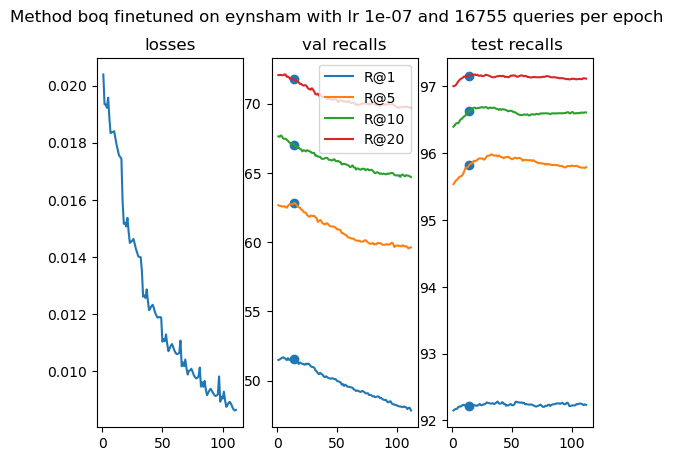

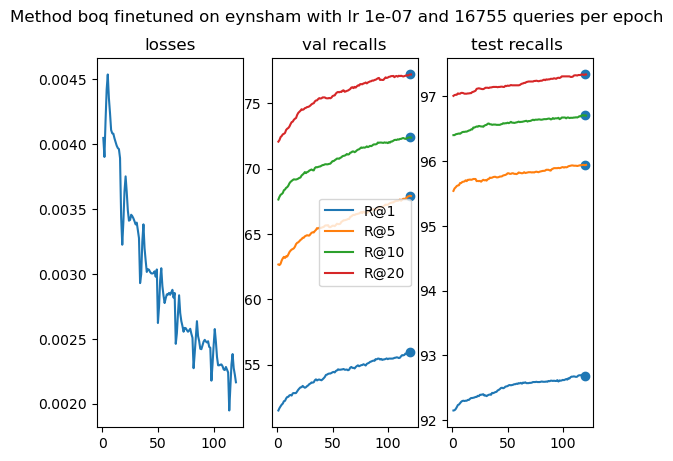

In [320]:
loss1=create_plot('boq','eynsham',lr=1e-7,num=1,show_num=show_num,dots=True,patience=patience,print_shizzl=True)
loss1=create_plot('boq','eynsham',lr=1e-7,num=5,show_num=show_num,dots=True,patience=patience,print_shizzl=True)


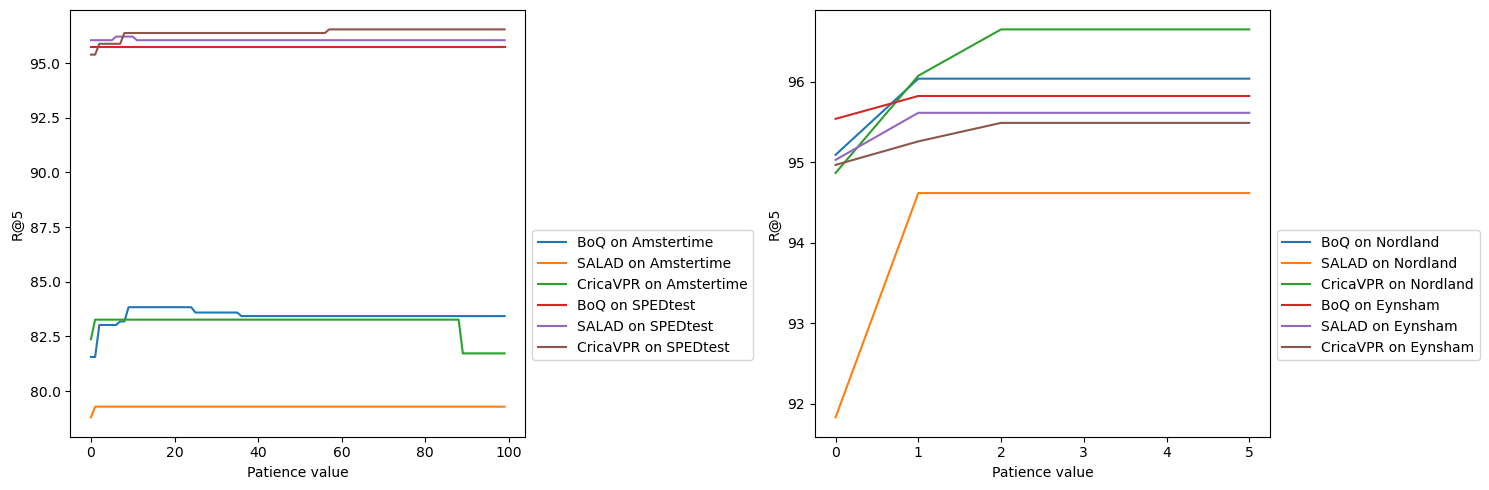

In [266]:
patience=100
show_num=-1
lr=1e-7
recall_value=1
dots=True
print_shizzl=True
titles=["R@1","R@5","R@10","R@20"]
# x=create_plot_r5_patience('boq','amstertime',lr=lr,num=1,show_num=show_num,dots=dots,patience_max=patience,print_shizzl=print_shizzl)
boq_ams=create_plot_r5_patience('boq','amstertime',lr=lr,num=1,show_num=show_num,dots=dots,patience_max=patience,print_shizzl=print_shizzl,recall_value=recall_value)
salad_ams=create_plot_r5_patience("salad",'amstertime',lr=1e-6,num=0,show_num=show_num,dots=dots,patience_max=patience,print_shizzl=print_shizzl,recall_value=recall_value)
crica_ams=create_plot_r5_patience('crica','amstertime',lr=1e-6,num=19,show_num=show_num,dots=dots,patience_max=patience,print_shizzl=print_shizzl,recall_value=recall_value)
boq_sped=create_plot_r5_patience('boq','sped',lr=lr,num=12,show_num=show_num,dots=True,patience_max=patience,print_shizzl=True,recall_value=recall_value)
salad_sped=create_plot_r5_patience("salad",'sped',lr=1e-6,num=0,show_num=show_num,dots=True,patience_max=patience,print_shizzl=True,recall_value=recall_value)
crica_sped=create_plot_r5_patience('crica','sped',lr=1e-6,num=1,show_num=show_num,dots=True,patience_max=patience,print_shizzl=True,recall_value=recall_value)

ams=np.array([boq_ams,salad_ams,crica_ams])
sped=np.array([boq_sped,salad_sped,crica_sped])
nord=np.array([create_plot_r5_patience('boq','nordland',lr=lr,num=0,show_num=show_num,dots=dots,patience_max=patience,print_shizzl=print_shizzl,recall_value=recall_value),
               create_plot_r5_patience('salad','nordland',lr=lr,num=0,show_num=show_num,dots=dots,patience_max=patience,print_shizzl=print_shizzl,recall_value=recall_value),
               create_plot_r5_patience('crica','nordland',lr=lr,num=16,show_num=show_num,dots=dots,patience_max=patience,print_shizzl=print_shizzl,recall_value=recall_value)])
eynsham=np.array([create_plot_r5_patience('boq','eynsham',lr=lr,num=1,show_num=show_num,dots=dots,patience_max=patience,print_shizzl=print_shizzl,recall_value=recall_value),
               create_plot_r5_patience('salad','eynsham',lr=lr,num=1,show_num=show_num,dots=dots,patience_max=patience,print_shizzl=print_shizzl,recall_value=recall_value),
               create_plot_r5_patience('crica','eynsham',lr=lr,num=8,show_num=show_num,dots=dots,patience_max=patience,print_shizzl=print_shizzl,recall_value=recall_value)])



# ax[0].set_title(f"{titles[recall_value]} on Amstertime and SPEDtest with different methods" )
if False:
    fig, ax=plt.subplots(1,1,figsize=[5,5])    
    ax.set_ylabel(f"{titles[recall_value]}")
    ax.set_xlabel(f"Patience value")
    # plt.show()
    # plt.plot([100,100],[95,100])
    ax.plot(sped[2].T)
    ax.plot(sped[1].T)
    ax.plot(sped[0].T)
    ax.plot(ams[0].T)
    ax.plot(ams[2].T)
    ax.plot(ams[1].T)
#     plt.plot([15,15],[78,98])
    ax.legend(labels=["CricaVPR on SPEDtest","SALAD on SPEDtest","BoQ on SPEDtest","BoQ on Amstertime","CricaVPR on Amstertime","SALAD on Amstertime"])
else:
    
    fig, ax=plt.subplots(1,2,figsize=[15,5])
    ax[0].set_ylabel(f"{titles[recall_value]}")
    ax[0].plot(ams.T)
    ax[0].set_xlabel(f"Patience value")
    # plt.show()
    # plt.plot([100,100],[95,100])
    ax[0].plot(sped.T)
    ax[0].legend(loc="upper left",bbox_to_anchor=(1, 0.5),labels=["BoQ on Amstertime","SALAD on Amstertime","CricaVPR on Amstertime","BoQ on SPEDtest","SALAD on SPEDtest","CricaVPR on SPEDtest"])

    # plt.show()
    plt.plot(nord.T[:6])

    # plt.show()
    plt.plot(eynsham.T[:6])
    ax[1].legend(loc="upper left",bbox_to_anchor=(1, 0.5),labels=["BoQ on Nordland","SALAD on Nordland","CricaVPR on Nordland","BoQ on Eynsham","SALAD on Eynsham","CricaVPR on Eynsham"])

    plt.ylabel(f"{titles[recall_value]}")

    plt.xlabel(f"Patience value")

plt.tight_layout()
plt.show()

5 25 True
original patience was 5
test recalls were [92.68017548 95.93482348 96.70357217 97.33444746] for the highest validation R@5
Original model results were [92.14957176 95.53791519 96.39857949 97.00438688] 
validation recalls were 67.92479108635098 for the highest validation R@5
Original model validation results were 62.66016713091922 
Early stopping not applied yet, best model is taken at 119, current logging num: 121
this run took 3 days, 1:30:32.596735 till Wed Dec 18 14:36:05 2024
6 10 False
original patience was 5
not stopped earlier
test recalls were [92.61332776 95.92228953 96.72446208 97.29684562] for the highest validation R@5
Original model results were [92.14957176 95.53791519 96.39857949 97.00438688] 
validation recalls were 66.76880222841226 for the highest validation R@5
Original model validation results were 60.61281337047354 
Early stopping not applied yet, best model is taken at 118, current logging num: 119
this run took 1 day, 23:45:23.509553 till Wed Dec 18 14:

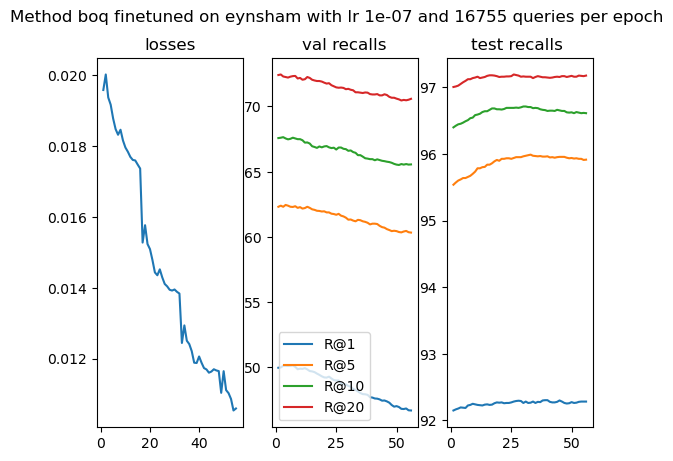

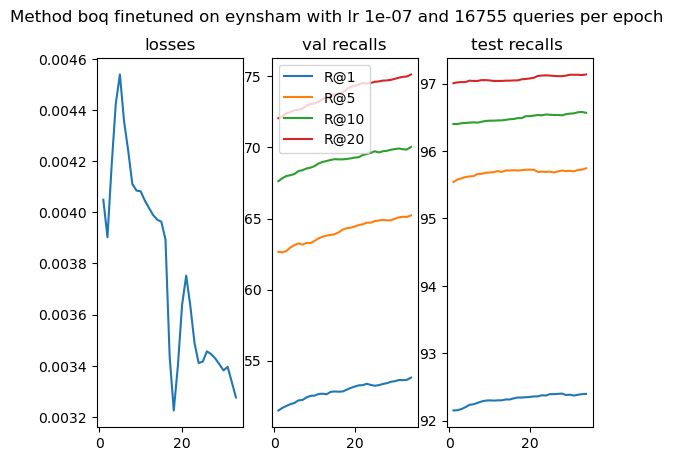

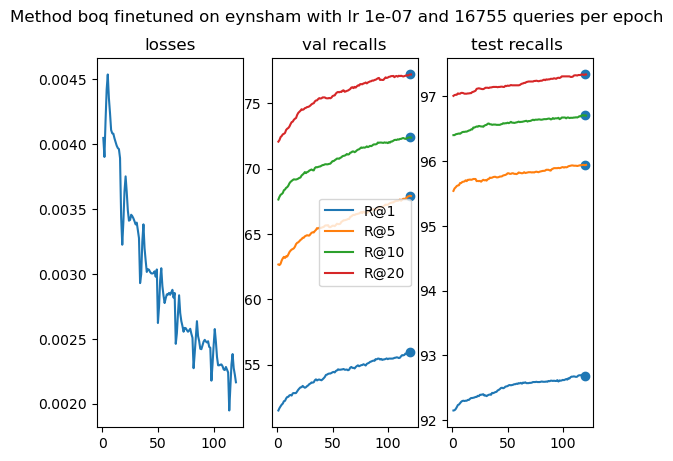

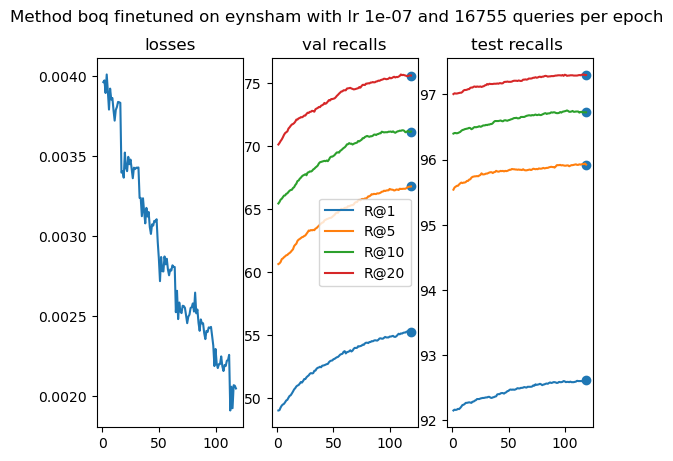

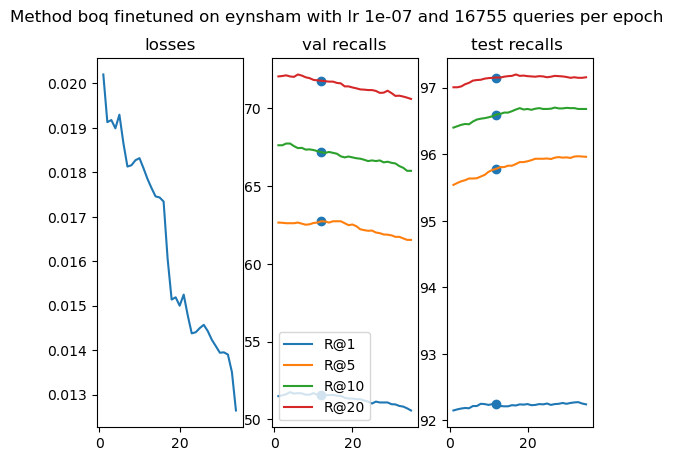

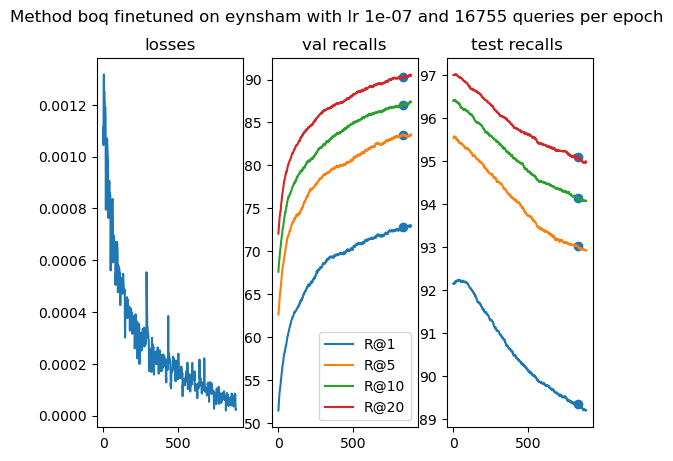

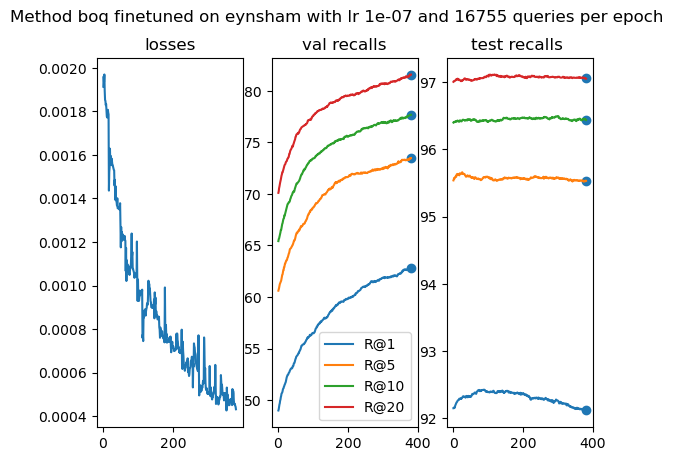

In [32]:

loss1=create_plot("boq",'eynsham',lr=1e-7,num="3",show_num=show_num,dots=True,patience=None,print_shizzl=print_shizzl)
loss1=create_plot("boq",'eynsham',lr=1e-7,num="4",show_num=show_num,dots=True,patience=None,print_shizzl=print_shizzl)
loss1=create_plot("boq",'eynsham',lr=1e-7,num="5",show_num=show_num,dots=True,patience=None,print_shizzl=print_shizzl)
loss1=create_plot("boq",'eynsham',lr=1e-7,num="6",show_num=show_num,dots=True,patience=None,print_shizzl=print_shizzl)
loss1=create_plot("boq",'eynsham',lr=1e-7,num="7",show_num=show_num,dots=True,patience=None,print_shizzl=print_shizzl)
# loss1=create_plot("boq",'eynsham',lr=1e-7,num="8",show_num=show_num,dots=True,patience=None,print_shizzl=print_shizzl)
# loss1=create_plot("boq",'eynsham',lr=1e-7,num="9",show_num=show_num,dots=True,patience=None,print_shizzl=print_shizzl)
loss1=create_plot("boq",'eynsham',lr=1e-7,num="10",show_num=show_num,dots=True,patience=None,print_shizzl=print_shizzl)
loss1=create_plot("boq",'eynsham',lr=1e-7,num="11",show_num=show_num,dots=True,patience=None,print_shizzl=print_shizzl)
# loss1=create_plot("crica",'nordland',lr=1e-6,num="8",show_num=show_num,dots=True,patience=None,print_shizzl=print_shizzl)
# loss1=create_plot("crica",'nordland',lr=1e-6,num="9",show_num=show_num,dots=True,patience=None,print_shizzl=print_shizzl)
# loss1=create_plot("salad",'nordland',lr=1e-7,num="5",show_num=show_num,dots=True,patience=None,print_shizzl=print_shizzl)
